C:\Users\Student\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



----------------------------------
Hidden Layers: [512, 256, 128]
Activation: relu
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.3237 - loss: 1.8670
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3967 - loss: 1.6734
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4329 - loss: 1.5845
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4538 - loss: 1.5267
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4705 - loss: 1.4820
Accuracy: 46.85 %

----------------------------------
Hidden Layers: [512, 256, 128]
Activation: tanh
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.2490 - loss: 2.0140
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3032 - loss: 1.9015
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3255 - loss: 1.8604
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3310 - loss: 1.8444
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━

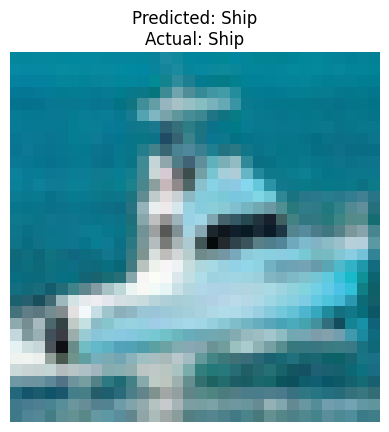

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.utils import to_categorical

class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

(x_train, y_train), (x_test, y_test) = cifar10.load_data()


x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


hidden_configs = [
    [512, 256, 128],
    [256, 128, 64],
    [128, 64, 32]
]


activations = ["relu", "tanh", "sigmoid"]

best_accuracy = 0
best_model = None


for hidden in hidden_configs:
    for activation in activations:

        print("\n----------------------------------")
        print("Hidden Layers:", hidden)
        print("Activation:", activation)

        model = Sequential([
            Input(shape=(32, 32, 3)),
            Flatten(),
            Dense(hidden[0], activation=activation),
            Dense(hidden[1], activation=activation),
            Dense(hidden[2], activation=activation),
            Dense(10, activation="softmax")
        ])

        model.compile(
            optimizer="adam",
            loss="categorical_crossentropy",
            metrics=["accuracy"]
        )

        model.fit(
            x_train,
            y_train_cat,
            epochs=5,
            batch_size=64,
            verbose=1
        )

        loss, accuracy = model.evaluate(
            x_test,
            y_test_cat,
            verbose=0
        )

        print("Accuracy:", round(accuracy * 100, 2), "%")

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = model
            best_hidden = hidden
            best_activation = activation

print("\n====================================")
print("Best Hidden Layers :", best_hidden)
print("Best Activation    :", best_activation)
print("Best Accuracy      :", round(best_accuracy * 100, 2), "%")

# Predict an image
index = int(input("\nEnter test image index (0-9999): "))

prediction = best_model.predict(np.expand_dims(x_test[index], axis=0))
predicted_class = np.argmax(prediction)

plt.imshow(x_test[index])
plt.title(
    f"Predicted: {class_names[predicted_class]}\n"
    f"Actual: {class_names[y_test[index][0]]}"
)
plt.axis("off")
plt.show()